# `allpass.py` — the example, run the way `tap.python~` runs it

`[tap.python~ allpass]` loads `python/allpass.py` and instantiates the class `allpass`. This notebook drives the same class in plain Python (no Max), the way the object does: it looks at what the object would expose, calls `prepare()` with the audio settings, then calls `process()` once per sample.

The object itself — loading, reloading, dispatch, the audio thread — is tested by the C++ core battery (`core/tests/`), which also runs this example. What this notebook shows is the DSP: that the filter really is an allpass, and that its delay follows the sample rate.

In [1]:
import inspect, typing
import numpy as np
import matplotlib.pyplot as plt

from allpass import allpass

## What `tap.python~` sees

The class's annotated public fields become Max attributes, typed by their hints; its public methods become messages. `process()` is the audio callback — per sample here, because its input is annotated `float` — and `prepare()` receives the audio settings. Names starting with `_` are private.

In [2]:
hints = typing.get_type_hints(allpass)
attributes = {name: hint.__name__ for name, hint in hints.items() if not name.startswith('_')}
methods = sorted(name for name, member in inspect.getmembers(allpass, inspect.isfunction)
                 if not name.startswith('_'))
print('attributes:', attributes)
print('messages:  ', [m for m in methods if m not in ('process', 'prepare')])
print('process:   ', inspect.signature(allpass.process))
print('prepare:   ', inspect.signature(allpass.prepare))

attributes: {'delay': 'float', 'alpha': 'float'}
messages:   ['clear']
process:    (self, x: float) -> float
prepare:    (self, sample_rate: float, vector_size: int) -> None


## Running it as the object does

The object calls `prepare(sample_rate, vector_size)` before any audio, then `process(x)` once per sample. With the defaults — a 1 ms delay and α = 0.5 — at 48 kHz the delay line is 48 samples.

In [3]:
fs = 48000.0
ap = allpass()
ap.prepare(fs, 64)

n = 48 * 400
impulse = np.zeros(n)
impulse[0] = 1.0
response = np.array([ap.process(x) for x in impulse])

print('first sample (alpha * x[0]):     ', response[0])
print('first echo at sample 48:         ', response[48])
print('energy of the impulse response:  ', np.sum(response ** 2))

Setting delay to 1.0 ms (48 samples @ 48000 Hz)
first sample (alpha * x[0]):      0.5
first echo at sample 48:          0.75
energy of the impulse response:   1.0


An allpass passes every frequency at unity gain and only shifts phase, so the impulse response keeps all of the impulse's energy (1.0 above), and its magnitude response is flat at 0 dB:

magnitude response: -0.000000 dB to 0.000000 dB


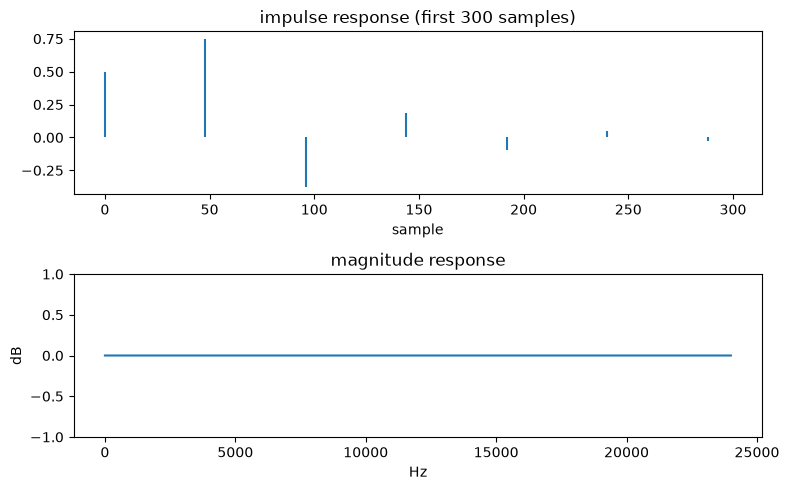

In [4]:
spectrum = np.fft.rfft(response)
freqs = np.fft.rfftfreq(n, 1 / fs)
magnitude_db = 20 * np.log10(np.abs(spectrum))
print(f'magnitude response: {magnitude_db.min():.6f} dB to {magnitude_db.max():.6f} dB')

fig, (a, b) = plt.subplots(2, 1, figsize=(8, 5))
a.stem(np.arange(300), response[:300], markerfmt=' ', basefmt=' ')
a.set_title('impulse response (first 300 samples)')
a.set_xlabel('sample')
b.plot(freqs, magnitude_db)
b.set_ylim(-1, 1)
b.set_title('magnitude response')
b.set_xlabel('Hz')
b.set_ylabel('dB')
fig.tight_layout()

## The delay follows the sample rate

Because the sample rate arrives through `prepare()`, the delay stays 1 ms at any rate — 96 samples at 96 kHz:

In [5]:
ap = allpass()
ap.prepare(96000.0, 64)
response = np.array([ap.process(x) for x in impulse[:400]])
print('silent until sample', np.flatnonzero(response[1:])[0] + 1)

Setting delay to 1.0 ms (48 samples @ 48000 Hz)
Setting delay to 1.0 ms (96 samples @ 96000 Hz)
silent until sample 96


## α stays inside the unit circle

At |α| = 1 the feedback pole sits on the unit circle and the filter never decays, so the class rejects it. In Max, the rejection is printed to the console and the attribute keeps its value.

In [6]:
ap = allpass()
try:
    ap.alpha = 1.0
except ValueError as e:
    print('rejected:', e)
print('alpha is still', ap.alpha)

Setting delay to 1.0 ms (48 samples @ 48000 Hz)
rejected: alpha must be strictly between -1.0 and 1.0
alpha is still 0.5
